# species.csv overview

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("data/raw/species.csv", sep="\t")
df.shape

C:\Users\Florian\AppData\Local\Temp\ipykernel_36088\3405938945.py:1: DtypeWarning: Columns (0: family_common_name, 1: flower_color, 2: flower_conspicuous, 3: foliage_color, 4: foliage_texture, 5: fruit_color, 6: fruit_conspicuous, 7: bloom_months, 8: growth_form, 9: growth_rate, 10: edible_part, 11: vegetable, 12: edible, 13: anaerobic_tolerance, 14: planting_description, 15: planting_sowing_description, 16: url_tropicos) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/raw/species.csv", sep="\t")


(416473, 54)

In [3]:
df[["id", "scientific_name", "genus", "family", "common_name"]].head()

,id,scientific_name,genus,family,common_name
0,101119,Abies balsamea,Abies,Pinaceae,Balsam fir
1,101124,Abies bracteata,Abies,Pinaceae,Bristlecone fir
2,101126,Abies concolor,Abies,Pinaceae,White fir
3,101129,Abies fraseri,Abies,Pinaceae,Fraser fir
4,101131,Abies grandis,Abies,Pinaceae,Grand fir


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 416473 entries, 0 to 416472
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           416473 non-null  int64  
 1   scientific_name              416473 non-null  str    
 2   rank                         416473 non-null  str    
 3   genus                        416473 non-null  str    
 4   family                       408435 non-null  str    
 5   year                         368655 non-null  float64
 6   author                       404731 non-null  str    
 7   bibliography                 386102 non-null  str    
 8   common_name                  38113 non-null   str    
 9   family_common_name           342023 non-null  str    
 10  image_url                    139027 non-null  str    
 11  flower_color                 4617 non-null    str    
 12  flower_conspicuous           2726 non-null    object 
 13  foliage_co

In [5]:
pd.Series({
    "rows": len(df),
    "columns": df.shape[1],
    "unique_id": df["id"].nunique(),
    "unique_scientific_name": df["scientific_name"].nunique(),
    "unique_family": df["family"].nunique(),
    "unique_genus": df["genus"].nunique(),
})

rows                      416473
columns                       54
unique_id                 416473
unique_scientific_name    416473
unique_family                580
unique_genus               15832
dtype: int64

In [6]:
missing = df.isna().sum().sort_values(ascending=False)
missing.head(15)

fruit_months                   416473
growth_months                  416473
url_openfarm                   416473
url_catminat                   416473
url_tela_botanica              416473
ground_humidity                416470
planting_description           416470
planting_days_to_harvest       416469
planting_spread_cm             416432
planting_row_spacing_cm        416430
planting_sowing_description    416424
edible_part                    416357
fruit_color                    414973
foliage_color                  414927
anaerobic_tolerance            414853
dtype: int64

In [7]:
top_families = df["family"].value_counts().head(10)
top_families

family
Asteraceae         44080
Orchidaceae        30132
Fabaceae           26010
Rubiaceae          15901
Poaceae            12892
Lamiaceae           9616
Apocynaceae         7834
Euphorbiaceae       7175
Cyperaceae          6815
Melastomataceae     6287
Name: count, dtype: int64

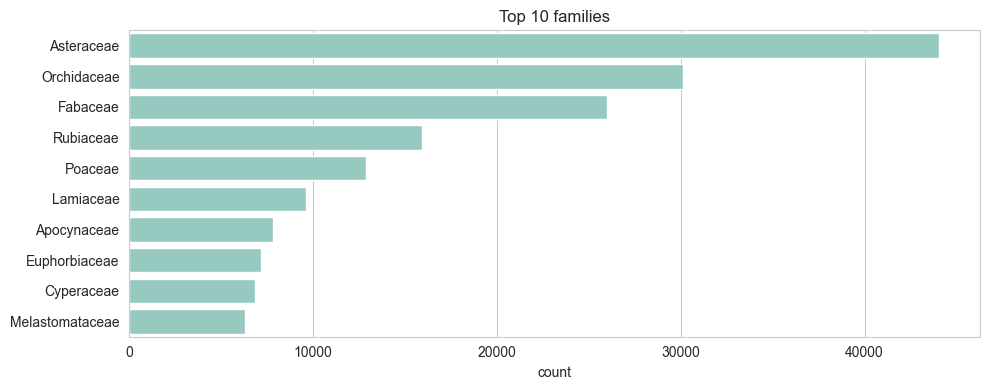

In [8]:
plt.figure(figsize=(10, 4))
sns.barplot(x=top_families.values, y=top_families.index)
plt.title("Top 10 families")
plt.xlabel("count")
plt.ylabel("")
plt.tight_layout()

In [9]:
denorm_cols = [
    "synonyms", "distributions", "common_names",
    "fruit_months", "bloom_months", "growth_months",
    "flower_color", "foliage_color", "fruit_color", "edible_part",
]

denorm_summary = pd.DataFrame({
    "non_null": df[denorm_cols].notna().sum(),
    "contains_comma": df[denorm_cols].fillna("").apply(lambda s: s.str.contains(",").sum())
}).sort_values("contains_comma", ascending=False)

denorm_summary

,non_null,contains_comma
distributions,347012,154622
synonyms,181892,103548
common_names,12383,8588
bloom_months,2133,2069
flower_color,4617,278
edible_part,116,11
fruit_color,1500,2
fruit_months,0,0
growth_months,0,0
foliage_color,1546,0


In [10]:
df[["synonyms", "distributions", "common_names"]].dropna(how="all").head(5)

,synonyms,distributions,common_names
0,"Pinus balsamea,Pinus taxifolia,Picea balsamea,...","Alberta,Connecticut,Iowa,Labrador,Maine,Manito...","Canada balsam,Balsam,Balsam fir,Fir balsam,Eas..."
1,"Abies venusta,Pinus bracteata,Picea bracteata,...",California,NaN
2,"Abies concolor var. lowiana,Abies concolor f. ...","Arizona,California,Colorado,Idaho,Mexico North...","Abeto blanco,Abeto del noroeste,Sierra White F..."
3,"Picea hudsonia,Abies balsamea subsp. fraseri,P...","North Carolina,Tennessee,Virginia","Fraser fir,Fraser balsam fir,Balsam fir,Easter..."
4,"Abies grandis var. idahoensis,Abies grandis f....","British Columbia,California,Idaho,Montana,Oreg...","Giant Fir,Grand fir,Lowland fir,Lowland white ..."
